In [101]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.preprocessing import label_binarize

In [102]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [103]:
df = pd.read_csv('/content/drive/MyDrive/ML CSE 3202/Iris.csv')

In [104]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [105]:
df.shape

(150, 6)

In [106]:
print(df.info)

<bound method DataFrame.info of       Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  \
0      1            5.1           3.5            1.4           0.2   
1      2            4.9           3.0            1.4           0.2   
2      3            4.7           3.2            1.3           0.2   
3      4            4.6           3.1            1.5           0.2   
4      5            5.0           3.6            1.4           0.2   
..   ...            ...           ...            ...           ...   
145  146            6.7           3.0            5.2           2.3   
146  147            6.3           2.5            5.0           1.9   
147  148            6.5           3.0            5.2           2.0   
148  149            6.2           3.4            5.4           2.3   
149  150            5.9           3.0            5.1           1.8   

            Species  
0       Iris-setosa  
1       Iris-setosa  
2       Iris-setosa  
3       Iris-setosa  
4       Iris-seto

In [107]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [108]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [109]:
df = df.drop('Id', axis=1)

In [110]:
df.isnull().sum()

,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [111]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Species'] = encoder.fit_transform(df['Species'])

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [112]:
df.tail()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


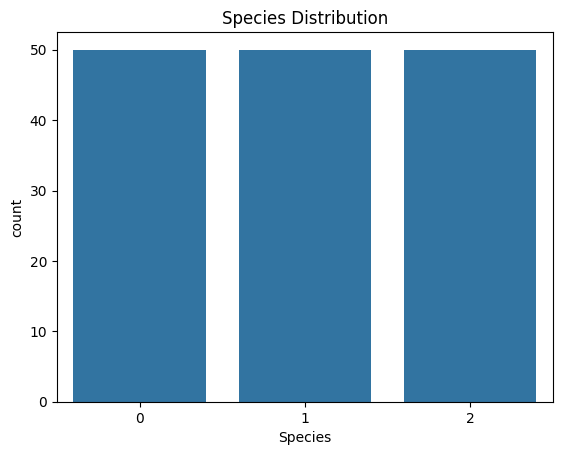

In [113]:
sns.countplot(x='Species', data=df)

plt.title('Species Distribution')

plt.show()

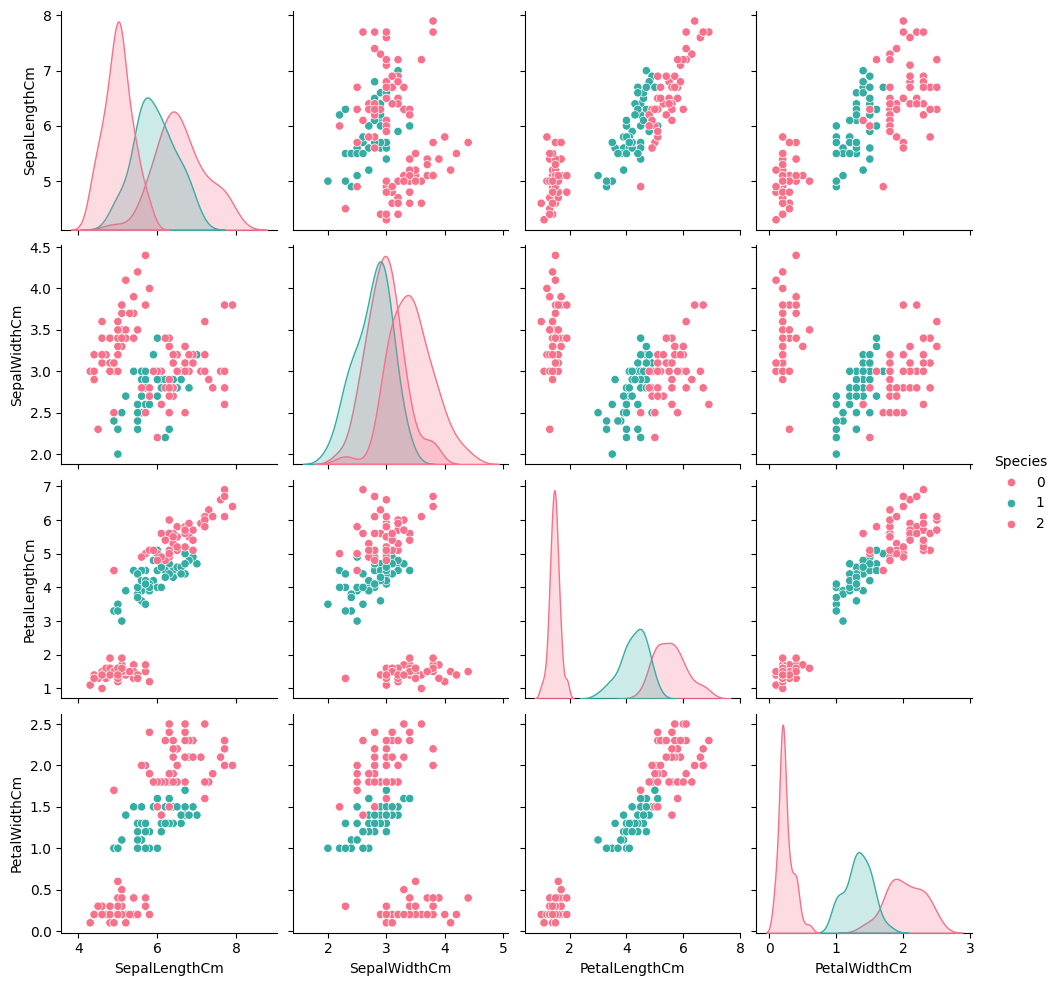

In [114]:
sns.pairplot(df, hue='Species', palette='husl')

plt.show()

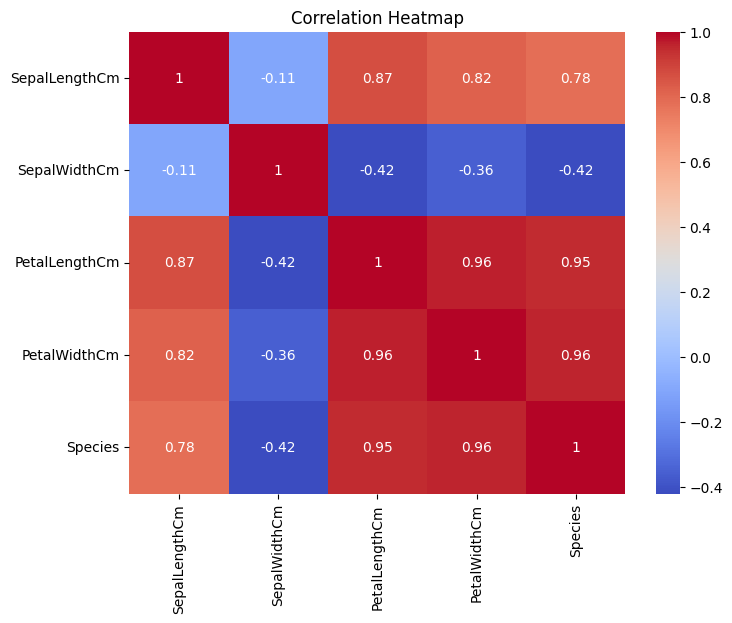

In [115]:
temp_df = df.copy()

temp_df['Species'] = temp_df['Species'].astype('category').cat.codes

plt.figure(figsize=(8,6))

sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap')

plt.show()

In [116]:
X = df.drop('Species', axis=1)

y = df['Species']

In [117]:
# First split: Train and temporary set

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# Second split: Validation and Test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Testing set size:", X_test.shape)

Training set size: (105, 4)
Validation set size: (22, 4)
Testing set size: (23, 4)


In [118]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [119]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter tuning

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['linear', 'rbf', 'poly'],
    'degree': [2, 3, 4]
}

grid = GridSearchCV(
    SVC(probability=True),
    param_grid,
    refit=True,
    verbose=2,
    cv=5
)

# Train model

grid.fit(X_train, y_train)

# Best parameters

print("Best Parameters:")
print(grid.best_params_)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ............C=0.1, degree=2, gamma=1, kernel=linear; total time=   0.0s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ...............C=0.1, degree=2, gamma=1, kernel=rbf; total time=   0.0s
[CV] END ..............C=0.1, degree=2, gamma=1, kernel=poly; total time=   0.0s
[CV] END ..............C=0.1, degree=2, gamma=

In [120]:
svm_model.fit(X_train, y_train)

SVC(kernel='linear')

In [121]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

In [122]:
# Validation prediction

val_pred = best_model.predict(X_val)

print("Validation Accuracy:",
      accuracy_score(y_val, val_pred))

Validation Accuracy: 0.9545454545454546


In [123]:
accuracy = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", accuracy)

SVM Accuracy: 1.0


In [124]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00         7

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



In [125]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 6  0  0]
 [ 0 10  0]
 [ 0  0  7]]


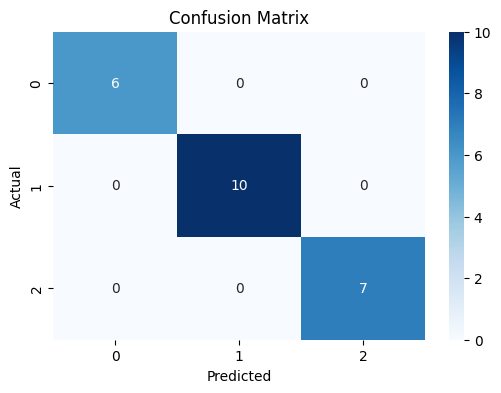

In [126]:
plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

In [127]:
y_pred = best_model.predict(X_test)

In [128]:
# Probability predictions

y_prob = best_model.predict_proba(X_test)

print(y_prob[:5])

[[9.99930006e-01 1.48988881e-05 5.50952738e-05]
 [8.67052723e-03 4.34286773e-03 9.86986605e-01]
 [2.93781321e-03 4.83394612e-04 9.96578792e-01]
 [9.94585018e-01 2.54712061e-03 2.86786093e-03]
 [1.60234989e-02 2.22291998e-02 9.61747301e-01]]


In [129]:
# Convert y_test into binary format

y_test_bin = label_binarize(y_test, classes=[0,1,2])

# Calculate AUC score

auc_score = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class='ovr'
)

print("AUC Score:", auc_score)

AUC Score: 1.0


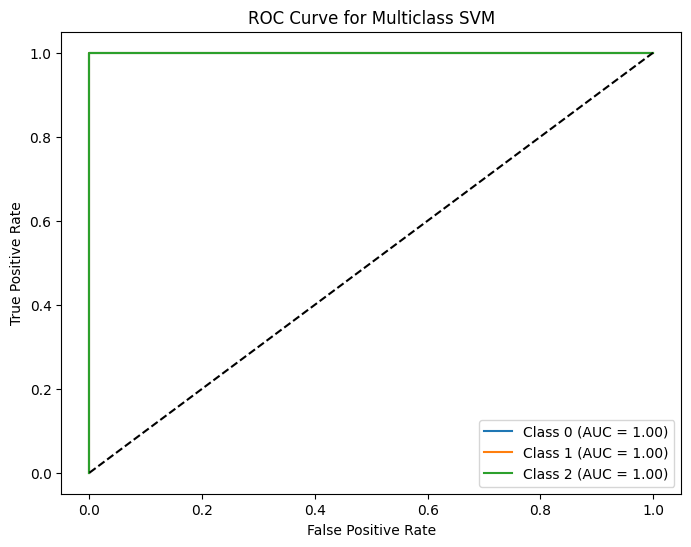

In [130]:
# ROC Curve

n_classes = 3

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):

    fpr[i], tpr[i], _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting

plt.figure(figsize=(8,6))

for i in range(n_classes):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f'Class {i} (AUC = {roc_auc[i]:.2f})'
    )

# Random line

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve for Multiclass SVM')

plt.legend()

plt.show()

In [131]:
# Reset index

y_test_reset = y_test.reset_index(drop=True)

# Sample prediction table

sample_results = pd.DataFrame({
    'Actual': y_test_reset,
    'Predicted': y_pred,
    'Probability': np.max(y_prob, axis=1)
})

sample_results.head(10)

,Actual,Predicted,Probability
0,0,0,0.999930
1,2,2,0.986987
2,2,2,0.996579
3,0,0,0.994585
4,2,2,0.961747
5,1,1,0.769661
6,1,1,0.778911
7,0,0,0.951607
8,1,1,0.519590
9,1,1,0.798196


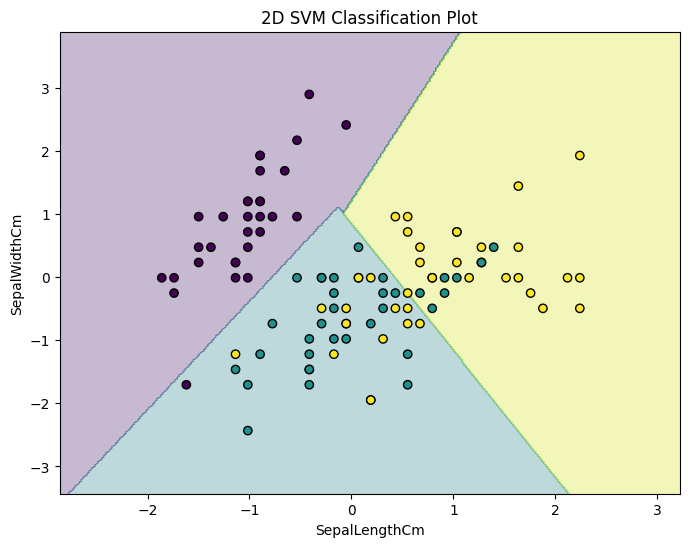

In [132]:
# 2D Classification Plot

from matplotlib.colors import ListedColormap

# Use only first two features

X_2d = X.iloc[:, :2]

y_2d = y

# Train-test split

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.3,
    random_state=42
)

# Scaling

scaler_2d = StandardScaler()

X_train_2d = scaler_2d.fit_transform(X_train_2d)

X_test_2d = scaler_2d.transform(X_test_2d)

# Train SVM

svm_2d = SVC(kernel='linear')

svm_2d.fit(X_train_2d, y_train_2d)

# Meshgrid

x_min, x_max = X_train_2d[:,0].min() - 1, X_train_2d[:,0].max() + 1

y_min, y_max = X_train_2d[:,1].min() - 1, X_train_2d[:,1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Predictions

Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])

Z = Z.reshape(xx.shape)

# Plot

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.3)

scatter = plt.scatter(
    X_train_2d[:,0],
    X_train_2d[:,1],
    c=y_train_2d,
    edgecolor='k'
)

plt.xlabel(X.columns[0])

plt.ylabel(X.columns[1])

plt.title('2D SVM Classification Plot')

plt.show()